In [1]:
import pandas as pd
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer as cv
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
stopw = stopwords.words('english')
stopw.extend(list(string.ascii_lowercase))
stopw.extend(['0','1','2','3','4','5','6','7','8','9','https','www','com'])
punctuation_ = string.punctuation + '1234567890Â©á»áº¯ÄÃ' + '¢`~¡¢£¤¥¦§¨©ª«¬®¯°±²³´µ¶·¸¹º»¼½¾¿×÷¢£¤¥¦§©´µ¶·¸¹º€£¥₹₽₿₣₱₩₨₫₮₭₣₢₥₦₠₡₧₤₮₯₰₲₱₴₵₸₹₺₻₼₽₿'


def my_review_filter(review):
    #rm punctuation
    list=[ch for ch in review if ch not in punctuation_]
    review = ''.join(list)
    #rm stopword
    list = [word for word in review.split() if word.lower() not in stopw]
    return list


df1 = pd.read_csv(r'../Dataset/pos_label.csv',encoding='latin-1')
df2 = pd.read_csv(r'../Dataset/neg_label.csv',encoding='latin-1')
df = pd.concat([df1,df2], ignore_index=True)
# df=df3


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kshitij\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
vector =cv(analyzer=my_review_filter, dtype=np.uint8)
X = vector.fit_transform(df['Comment'])
y = df['Label']

In [3]:
print(list(vector.vocabulary_.keys())[:10])

['LOVE', 'HealthUandPets', 'guys', 'best', 'im', 'meeting', 'one', 'besties', 'tonight', 'Cant']


In [5]:
X.shape

(1638475, 930643)

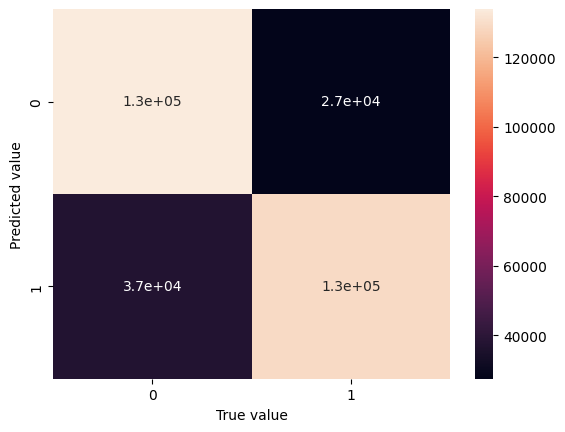

              precision    recall  f1-score   support

           0       0.78      0.83      0.81    161321
           1       0.82      0.78      0.80    166374

    accuracy                           0.80    327695
   macro avg       0.80      0.80      0.80    327695
weighted avg       0.80      0.80      0.80    327695



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=58)

NB_classifier = MultinomialNB()
NB_classifier.fit(X_train, y_train)

y_predict_test = NB_classifier.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True)
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

print(classification_report(y_test, y_predict_test))

In [ ]:
def get_confidence_scores(X):
    confidence_scores = NB_classifier.predict_proba(X)
    return confidence_scores

In [ ]:
l = ["wow that's beatiful","that's awful",'Hello my name is abc. XD', 'for real?', 'holy moly', '#you are fool dumb wit', 'nice', 'good game']
X_input = vector.transform(l)
res = NB_classifier.predict(X_input)
confidence_scores = get_confidence_scores(X_input)

for i in range(len(l)):
    print(f"The predicted value for {l[i]} is: ", end="")
    n = res[i]
    if n == 1:
        print(f'POSITIVE (confidence: {100*confidence_scores[i][1]:.2f})')
    else:
        print(f'NEGATIVE (confidence: {100*confidence_scores[i][0]:.2f})')


The predicted value for wow that's beatiful is: POSITIVE (confidence: 84.39)
The predicted value for that's awful is: NEGATIVE (confidence: 83.22)
The predicted value for Hello my name is abc. XD is: POSITIVE (confidence: 94.64)
The predicted value for for real? is: POSITIVE (confidence: 52.61)
The predicted value for holy moly is: NEGATIVE (confidence: 99.41)
The predicted value for #you are fool dumb wit is: NEGATIVE (confidence: 63.21)
The predicted value for nice is: POSITIVE (confidence: 71.61)
The predicted value for good game is: POSITIVE (confidence: 65.01)
